# Introduction to Python, Part V: Plotting with Matplotlib

In Part IV we covered NumPy: arrays and fast, vectorized math. In this notebook we make that math *visible*. We'll cover **Matplotlib**, the standard plotting library for Python, and its `pyplot` interface. Topics: the anatomy of a figure, basic 2D plots, multi-panel figures with `plt.subplots`, density/contour plots, choosing colors and colormaps, 3D plots, quick interactive/HTML plots, and animated GIFs.

Each section starts with a short explanation, followed by a code cell you can run and experiment with. Try changing values in the code cells, that's the best way to learn!

# Installing and Importing Matplotlib

Like NumPy, Matplotlib is a third-party package. From a terminal:

```
pip install matplotlib
```

or, inside a notebook cell:

```
%pip install matplotlib
```

The standard import brings in the `pyplot` module under the alias `plt` (just like `numpy` is imported as `np`):

In [1]:
# uncomment the following line to install matplotlib if it is not already installed in your environment
# %pip install matplotlib

import numpy as np              # We'll keep using NumPy to generate the data we plot
import matplotlib.pyplot as plt # The standard convention: import pyplot under the alias plt

print(plt.matplotlib.__version__) # Print the installed version of matplotlib

3.11.1


By default, when you call `plt.show()` (or, in a Jupyter notebook, simply let a plotting command be the last line in a cell) the figure is drawn inline, right below the cell. Some notebook setups need one extra line to guarantee this:

```
%matplotlib inline
```

This is usually the default in Jupyter already, but it doesn't hurt to be explicit about it.

In [2]:
%matplotlib inline

# The Anatomy of a Figure

Before making plots, it helps to know the vocabulary Matplotlib uses for the pieces of a plot (this mirrors the well-known "Anatomy of a Figure" diagram from the official Matplotlib documentation, see [Quick start guide](https://matplotlib.org/stable/users/explain/quick_start.html)):

- **Figure**: the whole window or page everything is drawn on. Created with `plt.figure()` or `fig, ax = plt.subplots()`. A figure can hold one or more Axes.
- **Axes**: a single plot inside the figure, i.e., the region bounded by the data area (despite the confusing name, one `Axes` is one subplot, not to be confused with the plural of "axis"). Has its own x-axis and y-axis.
- **Axis**: one of the number-lines bounding an Axes (`ax.xaxis`, `ax.yaxis`). Each Axis has **major/minor ticks**, **tick labels**, and an axis **label** (`ax.set_xlabel`, `ax.set_ylabel`).
- **Title**: text above the Axes, set with `ax.set_title()`.
- **Line / Markers**: the plotted data itself, drawn with `ax.plot()` (lines) or `ax.scatter()` (markers).
- **Legend**: a key mapping colors/styles to labels, added with `ax.legend()`.
- **Grid**: light reference lines behind the data, toggled with `ax.grid()`.
- **Spines**: the four lines forming the border of the Axes (`ax.spines['top']`, `['right']`, `['bottom']`, `['left']`).

The code below builds a small labeled diagram of these pieces so you can see where each one lives on an actual figure.

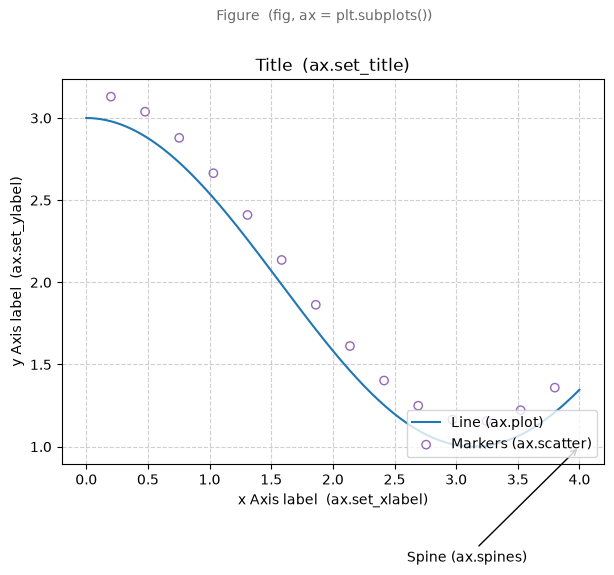

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))                    # fig = the whole Figure; ax = the one Axes inside it

x = np.linspace(0, 4, 200)                                 # 200 x values from 0 to 4
ax.plot(x, np.cos(x) + 2, color="tab:blue", label="Line (ax.plot)")     # A Line
ax.scatter(np.linspace(0.2, 3.8, 14),                        # A scattering of Markers
           np.cos(np.linspace(0.2, 3.8, 14)) + 2 + 0.15,
           facecolors="none", edgecolors="tab:purple", label="Markers (ax.scatter)")

ax.set_title("Title  (ax.set_title)")                       # Title
ax.set_xlabel("x Axis label  (ax.set_xlabel)")               # x-axis label
ax.set_ylabel("y Axis label  (ax.set_ylabel)")               # y-axis label
ax.legend(loc="lower right")                                # Legend
ax.grid(True, linestyle="--", alpha=0.6)                    # Grid

ax.annotate("Spine (ax.spines)", xy=(4, 1), xytext=(2.6, 0.3),
            arrowprops=dict(arrowstyle="->"))                # Point at the right spine
ax.annotate("Major tick (ax.xaxis.set_major_locator)", xy=(3, 0.65),
            xytext=(1.6, 3.6), arrowprops=dict(arrowstyle="->"))

fig.suptitle("Figure  (fig, ax = plt.subplots())", y=1.02, fontsize=10, color="dimgray")

plt.show()

# Making a Basic Plot: `fig, ax = plt.subplots()`

Matplotlib actually offers two interfaces:

1. The **pyplot (state-based) interface**: quick one-liners like `plt.plot(x, y)`, `plt.title(...)`. Matplotlib keeps track of "the current figure/axes" behind the scenes for you.
2. The **object-oriented (OO) interface**: you explicitly create a `Figure` and one or more `Axes` objects, and call methods on them: `ax.plot(x, y)`, `ax.set_title(...)`.

The pyplot interface is convenient for a single, throwaway plot in an interactive session. The OO interface is the recommended approach for anything else, including multi-panel figures, because it's explicit about *which* Axes you're drawing on. We'll use the OO interface throughout this notebook. The general pattern:

```
fig, ax = plt.subplots()   # Create one Figure containing one Axes
ax.plot(x, y)               # Draw on that Axes
plt.show()                  # Render the figure
```

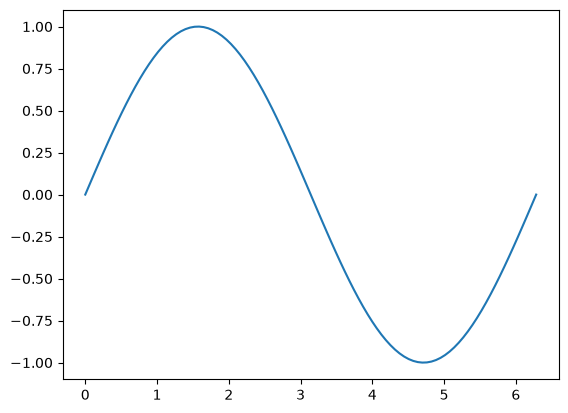

In [4]:
x = np.linspace(0, 2 * np.pi, 100)   # 100 x values from 0 to 2*pi
y = np.sin(x)                         # y = sin(x) at each of those points

fig, ax = plt.subplots()              # Create a Figure and a single Axes inside it
ax.plot(x, y)                         # Plot y vs. x as a line on that Axes
plt.show()                            # Render the figure

Compare the same plot using the pyplot (state-based) shortcut, `plt.plot(...)` directly, with no explicit `fig, ax`. It looks almost identical for one simple plot, but there's no named `ax` to refer back to, which becomes limiting the moment you want more than one panel:

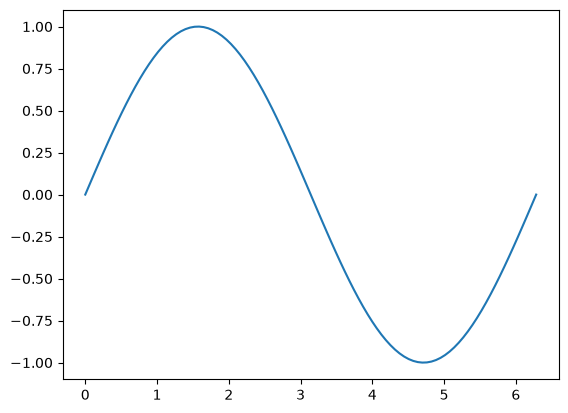

In [5]:
plt.plot(x, y)  # pyplot draws on "whatever the current axes is", creating one if needed
plt.show()

# Customizing a Plot

Common customizations, all done through keyword arguments to `ax.plot()` or through methods on `ax`:

| What | How |
|---|---|
| Color | `ax.plot(x, y, color="tab:red")` (or shorthand `"r"`) |
| Line style | `ax.plot(x, y, linestyle="--")` (`"-"`, `"--"`, `":"`, `"-."`) |
| Line width | `ax.plot(x, y, linewidth=2)` |
| Markers | `ax.plot(x, y, marker="o")` |
| Label (for legend) | `ax.plot(x, y, label="sin(x)")` then `ax.legend()` |
| Title | `ax.set_title("...")` |
| Axis labels | `ax.set_xlabel("...")`, `ax.set_ylabel("...")` |
| Axis limits | `ax.set_xlim(0, 10)`, `ax.set_ylim(-1, 1)` |
| Grid | `ax.grid(True)` |

A shorthand string like `"ro--"` combines color (`r`=red), marker (`o`=circle) and linestyle (`--`=dashed) in one argument.

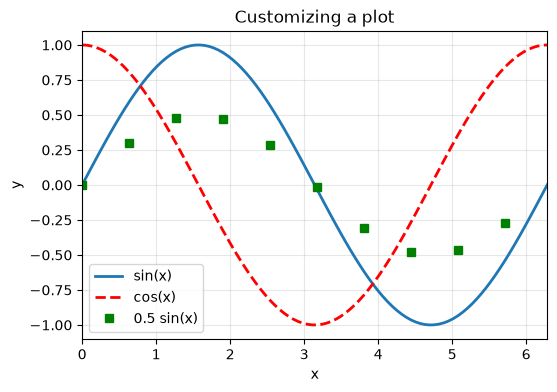

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))               # A slightly wider figure

ax.plot(x, np.sin(x), color="tab:blue", linewidth=2, label="sin(x)")            # Solid blue line
ax.plot(x, np.cos(x), "r--", linewidth=2, label="cos(x)")                       # Shorthand: red dashed line
ax.plot(x[::10], np.sin(x[::10]) * 0.5, "gs", markersize=6, label="0.5 sin(x)") # Shorthand: green squares, no line

ax.set_title("Customizing a plot")   # Title
ax.set_xlabel("x")                   # x-axis label
ax.set_ylabel("y")                   # y-axis label
ax.set_xlim(0, 2 * np.pi)            # Restrict the x-axis to exactly the data range
ax.grid(True, alpha=0.3)             # A subtle grid
ax.legend()                          # Show the legend using each plot's "label"
plt.show()

# Multiple Panels with `plt.subplots`

So far we've called `plt.subplots()` with no arguments, which gives one Figure with one Axes. Its general form is:

```
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=None, sharex=False, sharey=False)
```

- `nrows`, `ncols`: how many rows and columns of panels to lay out in a grid.
- `figsize`: `(width, height)` in inches for the whole figure.
- `sharex`, `sharey`: if `True`, all panels share the same x-axis (or y-axis) limits and ticks, useful for fair visual comparison across panels.

When `nrows * ncols > 1`, the second return value `axs` is a NumPy array of `Axes` objects instead of a single `Axes`. If your grid is 1D (either `nrows=1` or `ncols=1`), index it like `axs[i]`; if it's 2D, index it like `axs[row, col]`. A common trick is to call `.flatten()` on a 2D grid of axes so you can loop over every panel with a single `for` loop, regardless of the grid's shape.

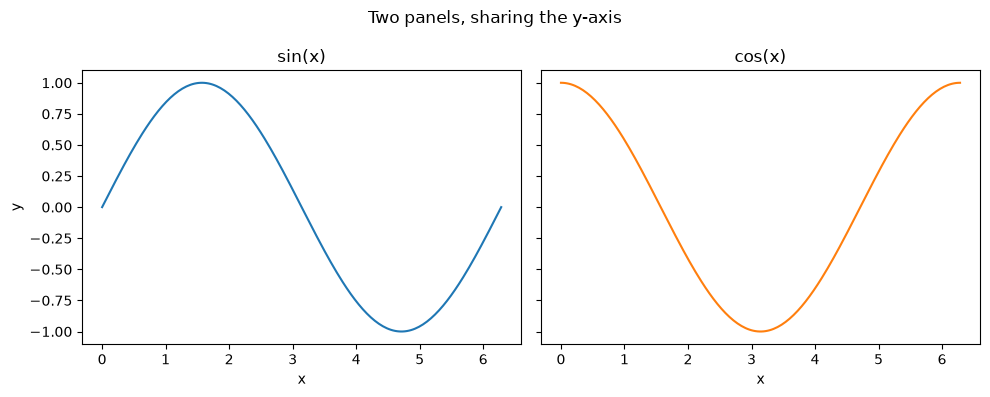

In [7]:
x = np.linspace(0, 2 * np.pi, 200)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True)  # 1 row, 2 columns, sharing the y-axis

axs[0].plot(x, np.sin(x), color="tab:blue")   # Draw on the LEFT panel
axs[0].set_title("sin(x)")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")

axs[1].plot(x, np.cos(x), color="tab:orange") # Draw on the RIGHT panel
axs[1].set_title("cos(x)")
axs[1].set_xlabel("x")

fig.suptitle("Two panels, sharing the y-axis")  # A single title spanning the whole figure
plt.tight_layout()                              # Adjust spacing so labels don't overlap
plt.show()

A 2x2 grid works the same way, but `axs` is now 2-dimensional. Here we loop over a 2x2 grid of Axes with `axs.flatten()` and a list of `(function, name)` pairs, plotting one function per panel:

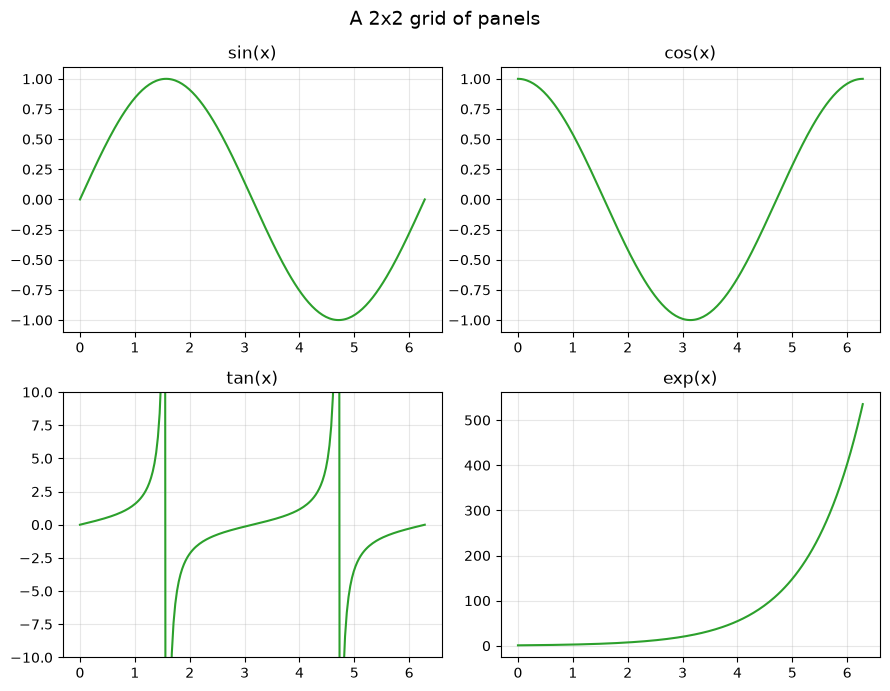

In [8]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(9, 7))  # A 2x2 grid: 4 panels total

functions = [
    (np.sin, "sin(x)"),
    (np.cos, "cos(x)"),
    (np.tan, "tan(x)"),
    (np.exp, "exp(x)"),
]

for ax, (func, name) in zip(axs.flatten(), functions):  # axs.flatten() turns the 2x2 grid into a flat list of 4 Axes
    ax.plot(x, func(x), color="tab:green")
    ax.set_title(name)
    ax.grid(True, alpha=0.3)

if functions[2][0] is np.tan:            # tan(x) blows up near pi/2; clip the y-axis so the plot stays readable
    axs.flatten()[2].set_ylim(-10, 10)

fig.suptitle("A 2x2 grid of panels", fontsize=14)
plt.tight_layout()
plt.show()

# Density Plots and Contour Plots

So far every plot has taken a 1D array of x-values and a 1D array of y-values. To visualize a function of **two** variables, $z = f(x, y)$, we need a grid of $(x, y)$ points and the value of $z$ at each one. NumPy's `np.meshgrid` builds that grid for us:

```
X, Y = np.meshgrid(x, y)
```

Given a 1D array `x` of length $m$ and a 1D array `y` of length $n$, `np.meshgrid` returns two 2D arrays `X` and `Y`, each of shape `(n, m)`, such that `X[i, j] = x[j]` and `Y[i, j] = y[i]`. In other words, `(X[i, j], Y[i, j])` is one point on the grid. You can then evaluate any function of `X` and `Y` elementwise (thanks to NumPy's vectorization from Part IV) to get a matrix `Z` of values, one per grid point.

With `X`, `Y`, and `Z` in hand, there are three common ways to visualize the surface $z = f(x, y)$:

- **`ax.contour(X, Y, Z)`**: draws contour *lines* (curves of constant $z$), like a topographic map.
- **`ax.contourf(X, Y, Z)`**: same idea, but *filled* with color between contour lines, this is the classic "density plot" look.
- **`ax.imshow(Z)`** or **`ax.pcolormesh(X, Y, Z)`**: colors every grid cell directly according to its `Z` value, without computing contour lines at all. This is the fastest option and works well for noisy or high-resolution data.

Add a **colorbar** with `fig.colorbar(...)` so the reader can read numeric `z` values off the color.

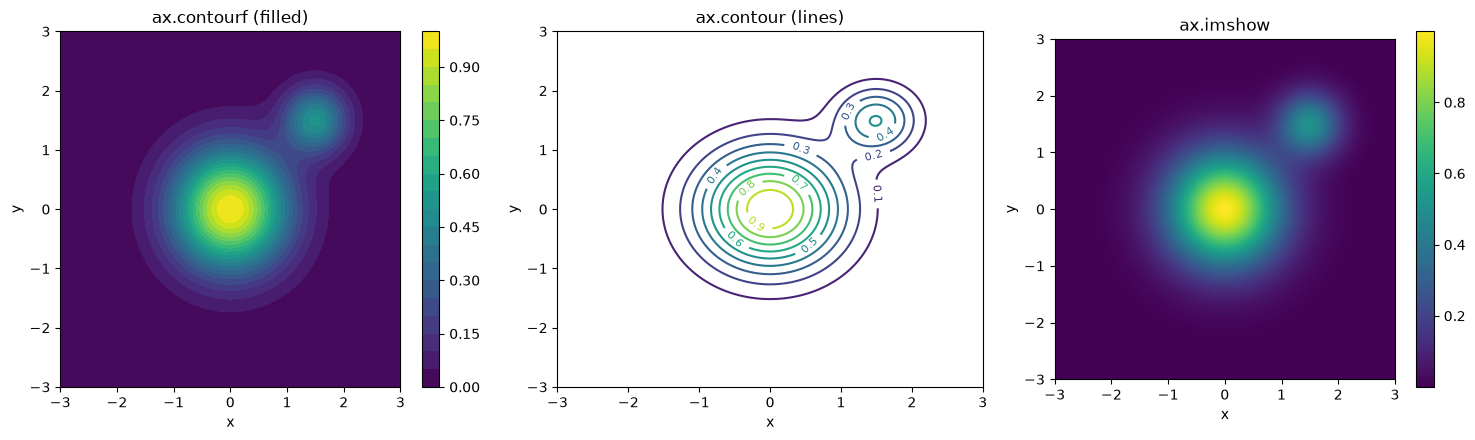

In [9]:
x = np.linspace(-3, 3, 200)   # 200 x-values from -3 to 3
y = np.linspace(-3, 3, 200)   # 200 y-values from -3 to 3
X, Y = np.meshgrid(x, y)      # X and Y are now both 200x200 grids of coordinates

Z = np.exp(-(X**2 + Y**2)) + 0.5 * np.exp(-((X - 1.5)**2 + (Y - 1.5)**2) / 0.3)  # A "bump" function: two overlapping Gaussians

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))

cf = axs[0].contourf(X, Y, Z, levels=20, cmap="viridis")  # Filled contour ("density") plot, 20 shades
fig.colorbar(cf, ax=axs[0])
axs[0].set_title("ax.contourf (filled)")

cl = axs[1].contour(X, Y, Z, levels=10, cmap="viridis")   # Contour LINES only
axs[1].clabel(cl, inline=True, fontsize=8)                # Label a few contour lines with their z value
axs[1].set_title("ax.contour (lines)")

im = axs[2].imshow(Z, extent=[-3, 3, -3, 3], origin="lower", cmap="viridis")  # Raw grid of colored cells
fig.colorbar(im, ax=axs[2])
axs[2].set_title("ax.imshow")

for ax in axs:
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()

`ax.contourf`/`ax.contour`/`ax.imshow` all visualize a function you already have a formula for. A closely related but different task is visualizing where a **cloud of scattered data points** is dense versus sparse; `ax.hist2d(x, y)` bins the points into a 2D grid of rectangles and colors each rectangle by how many points fell inside it, essentially a 2D histogram:

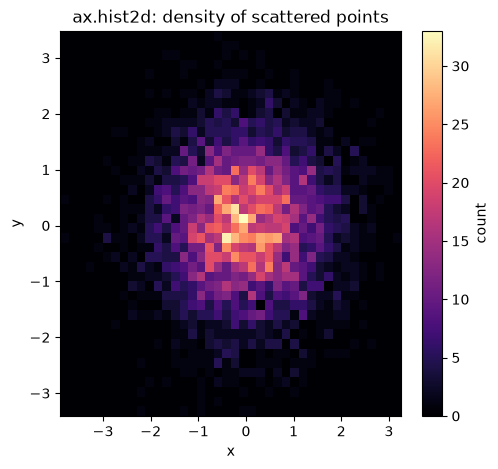

In [10]:
rng = np.random.default_rng(0)                      # A seeded random number generator, for reproducibility
pts_x = rng.normal(loc=0, scale=1, size=5000)        # 5000 random x-values from a normal distribution
pts_y = rng.normal(loc=0, scale=1, size=5000)        # 5000 random y-values from a normal distribution

fig, ax = plt.subplots(figsize=(5.5, 5))
h = ax.hist2d(pts_x, pts_y, bins=40, cmap="magma")   # 2D histogram: 40x40 bins, colored by point count per bin
fig.colorbar(h[3], ax=ax, label="count")             # h[3] is the QuadMesh object hist2d returns; used here to build the colorbar
ax.set_title("ax.hist2d: density of scattered points")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

# Choosing Colors and Colormaps

Two different situations call for two different kinds of color choices in Matplotlib:

1. **A single color per line/marker** (e.g. `color="tab:blue"`). Matplotlib accepts named colors (`"red"`, `"tab:blue"`), hex codes (`"#1f77b4"`), or the `"tab:..."` palette (`tab:blue`, `tab:orange`, `tab:green`, `tab:red`, `tab:purple`, ...), which is the default cycle used automatically when you don't specify a color at all.
2. **A colormap (`cmap=...`)**, used whenever color itself encodes a *continuous numeric value*, like the `Z` heights in the contour plots above. Picking the right colormap is important: the wrong one can visually distort your data or make it unreadable to colorblind viewers. Following Matplotlib's own [colormap guide](https://matplotlib.org/stable/users/explain/colors/colormaps.html), colormaps fall into a few families:

| Family | Use for | Examples |
|---|---|---|
| **Sequential** | Data that goes from low to high, with no natural "zero" (density, elevation, counts) | `viridis`, `plasma`, `magma`, `cividis` |
| **Diverging** | Data with a meaningful midpoint that values deviate from in two directions (e.g. temperature anomaly, profit/loss) | `coolwarm`, `RdBu`, `seismic` |
| **Qualitative** | Categorical data with no inherent order (different groups/classes) | `tab10`, `Set2`, `Pastel1` |
| **Cyclic** | Data that wraps around (angles, phase, time of day) | `twilight`, `hsv` |

`viridis` is Matplotlib's default colormap, and for good reason: it's **perceptually uniform** (equal steps in data look like equal steps in color) and remains readable if printed in grayscale or viewed by someone with red-green colorblindness. Rainbow-style maps like the old default `jet` are visually striking but can create false visual boundaries in the data and are generally discouraged today.

The code below previews one colormap from each family, and shows the default color cycle used for lines.

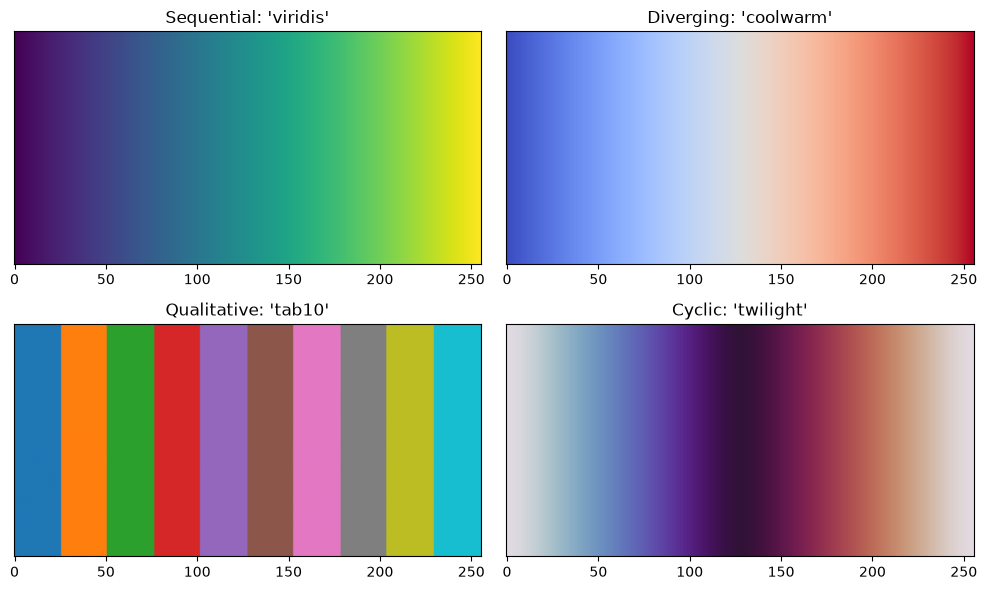

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
gradient = np.linspace(0, 1, 256).reshape(1, -1)  # A single row of 256 values from 0 to 1, used just to preview a colormap

for ax, cmap_name, family in zip(
    axs.flatten(),
    ["viridis", "coolwarm", "tab10", "twilight"],
    ["Sequential", "Diverging", "Qualitative", "Cyclic"],
):
    ax.imshow(gradient, aspect="auto", cmap=cmap_name)  # Stretch the gradient across the panel, colored by cmap_name
    ax.set_title(f"{family}: '{cmap_name}'")
    ax.set_yticks([])   # This is just a color strip, a y-axis would be meaningless

plt.tight_layout()
plt.show()

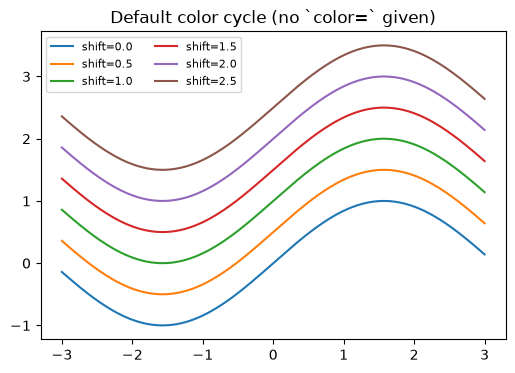

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))

for i in range(6):                                    # Draw 6 lines with NO color specified
    ax.plot(x, np.sin(x) + i * 0.5, label=f"shift={i * 0.5}")  # Matplotlib cycles through tab10 automatically

ax.set_title("Default color cycle (no `color=` given)")
ax.legend(fontsize=8, ncol=2)
plt.show()

When your colormap represents a *diverging* quantity (values above and below some meaningful center, often 0), it's important that the center of the colormap lines up with that meaningful value, not just with the midpoint of your data's min and max. `matplotlib.colors.TwoSlopeNorm` (or the simpler `CenteredNorm`) handles this for you:

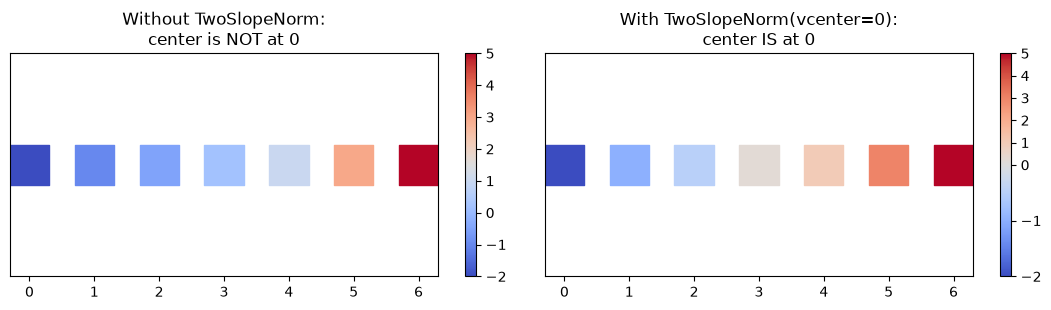

In [13]:
from matplotlib.colors import TwoSlopeNorm

temp_anomaly = np.array([-2, -1, -0.5, 0.2, 1, 3, 5])  # Mostly small negative values, one large positive outlier
x_labels = np.arange(len(temp_anomaly))

fig, axs = plt.subplots(1, 2, figsize=(11, 3.2))

norm_bad = plt.Normalize(vmin=temp_anomaly.min(), vmax=temp_anomaly.max())  # Naive min/max normalization: center is NOT at 0
sc0 = axs[0].scatter(x_labels, [0] * len(temp_anomaly), c=temp_anomaly, cmap="coolwarm", norm=norm_bad, s=800, marker="s")
fig.colorbar(sc0, ax=axs[0])
axs[0].set_title("Without TwoSlopeNorm:\ncenter is NOT at 0")

norm_good = TwoSlopeNorm(vmin=temp_anomaly.min(), vcenter=0, vmax=temp_anomaly.max())  # Force white/center at 0
sc1 = axs[1].scatter(x_labels, [0] * len(temp_anomaly), c=temp_anomaly, cmap="coolwarm", norm=norm_good, s=800, marker="s")
fig.colorbar(sc1, ax=axs[1])
axs[1].set_title("With TwoSlopeNorm(vcenter=0):\ncenter IS at 0")

for ax in axs:
    ax.set_yticks([])

plt.tight_layout()
plt.show()

# 3D Plots

Matplotlib's `mplot3d` toolkit adds a third dimension to Axes. You get a 3D Axes by passing `projection="3d"` to `add_subplot` (or to `plt.subplots(subplot_kw={"projection": "3d"})`). Once you have a 3D Axes, three plotting calls cover most needs:

- **`ax.plot3D(x, y, z)`**: a 3D line/curve, given three 1D arrays.
- **`ax.scatter3D(x, y, z)`**: a 3D scatter plot of points.
- **`ax.plot_surface(X, Y, Z)`**: a full surface, given the same kind of `X, Y, Z` meshgrid we built for contour plots.

3D plots are genuinely interactive when running with an interactive backend (drag to rotate); in a static notebook export you can still set a fixed viewing angle with `ax.view_init(elev=..., azim=...)`.

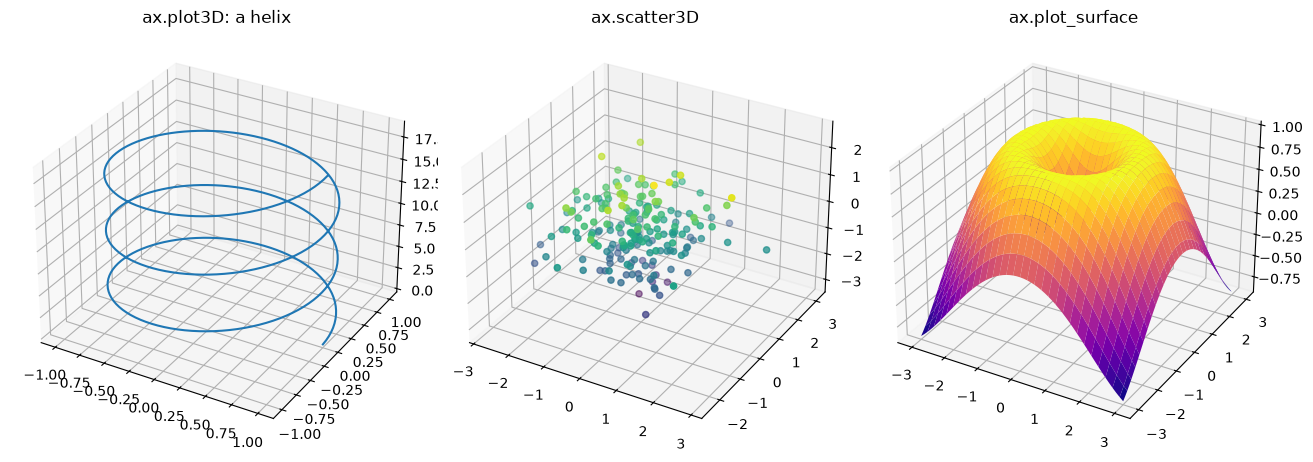

In [14]:
from mpl_toolkits.mplot3d import Axes3D  # Registers the '3d' projection with matplotlib

fig = plt.figure(figsize=(13, 5))

# --- Panel 1: a 3D curve (a helix) ---
ax1 = fig.add_subplot(1, 3, 1, projection="3d")
t = np.linspace(0, 6 * np.pi, 300)
ax1.plot3D(np.cos(t), np.sin(t), t, color="tab:blue")  # x=cos(t), y=sin(t), z=t traces a helix
ax1.set_title("ax.plot3D: a helix")

# --- Panel 2: a 3D scatter ---
ax2 = fig.add_subplot(1, 3, 2, projection="3d")
rng = np.random.default_rng(1)
xs, ys, zs = rng.normal(size=(3, 200))                  # 200 random points in 3D
sca = ax2.scatter3D(xs, ys, zs, c=zs, cmap="viridis")   # Color each point by its z value
ax2.set_title("ax.scatter3D")

# --- Panel 3: a surface, reusing the meshgrid idea from the contour section ---
ax3 = fig.add_subplot(1, 3, 3, projection="3d")
x2 = np.linspace(-3, 3, 60)
y2 = np.linspace(-3, 3, 60)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = np.sin(np.sqrt(X2**2 + Y2**2))                     # A "ripple" function
ax3.plot_surface(X2, Y2, Z2, cmap="plasma")
ax3.set_title("ax.plot_surface")
ax3.view_init(elev=30, azim=-60)                        # Fix the viewing angle for a static export

plt.tight_layout()
plt.show()

# Interactive and HTML Plots

Everything so far has produced a static image. Two easy ways to get interactivity, especially useful for 3D plots and plots with a lot of detail to zoom into:

**1. An interactive backend, inside a notebook.** Running the magic command

```
%matplotlib widget
```

(requires `%pip install ipympl` once) switches Matplotlib into a mode where every figure is a live, zoomable/pannable/rotatable widget embedded in the notebook, instead of a static image. This is the quickest way to interactively spin a 3D plot around.

**2. A standalone interactive HTML file**, that you can email or open in any browser without Python installed, using the third-party package `mpld3` (`%pip install mpld3`). It converts a Matplotlib figure into an HTML page with pan/zoom powered by D3.js:

```
import mpld3
mpld3.save_html(fig, "my_plot.html")   # Writes a standalone, interactive HTML file
```

The code below builds a plot and exports it to HTML this way (this cell will raise an `ImportError` with a helpful message if `mpld3` isn't installed, since it's an optional extra rather than a core dependency).

In [ ]:
# %pip install mpld3 ipympl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 3.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [ipympl]2m3/4 [ipympl]
Note: you may need to restart the kernel to use updated packages.


Saved interactive_plot.html . open it in a browser to pan and zoom!


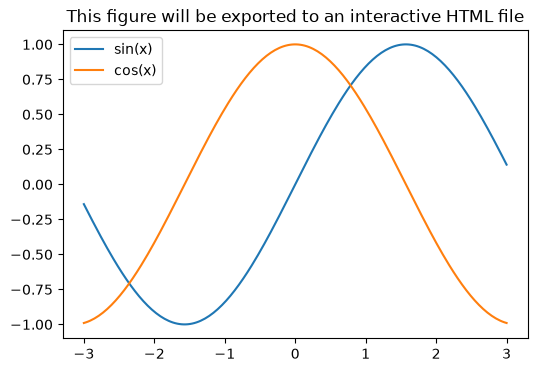

In [30]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, np.sin(x), label="sin(x)")
ax.plot(x, np.cos(x), label="cos(x)")
ax.set_title("This figure will be exported to an interactive HTML file")
ax.legend()

try:
    import mpld3
    mpld3.save_html(fig, "interactive_plot.html")  # Writes a standalone HTML file with pan/zoom
    print("Saved interactive_plot.html . open it in a browser to pan and zoom!")
except ImportError:
    print("mpld3 isn't installed. Run `%pip install mpld3` and re-run this cell to export an interactive HTML plot.")

plt.show()

# Creating Animated GIFs

Matplotlib's `matplotlib.animation` module can turn a *sequence* of plots into an animation, which you can then save as a `.gif`. The pattern has three parts:

1. Create a Figure and an initial, empty (or first-frame) plot, keeping a handle to the plotted object (e.g. the `Line2D` returned by `ax.plot(...)`).
2. Write an **update function** `update(frame)` that changes the data of that plotted object (e.g. `line.set_data(x, new_y)`) for a given frame number, and returns it.
3. Build a `FuncAnimation(fig, update, frames=..., interval=...)` and save it with `anim.save("name.gif", writer=PillowWriter(fps=...))`. `PillowWriter` comes from the `Pillow` image library and needs no extra installation beyond `pip install pillow`, which most environments already have.

`interval` is the delay between frames in **milliseconds** while animating live; `fps` (frames per second) controls the playback speed of the *saved* GIF file, they're set independently.

In [16]:
from matplotlib.animation import FuncAnimation, PillowWriter

fig, ax = plt.subplots(figsize=(5, 3.5))
x_anim = np.linspace(0, 2 * np.pi, 200)
line, = ax.plot(x_anim, np.sin(x_anim), color="tab:blue")  # Plot the first frame, keep a handle to the Line2D object

ax.set_ylim(-1.5, 1.5)
ax.set_title("A traveling sine wave")

def update(frame):
    phase = frame * 0.1                              # How far the wave has shifted by this frame
    line.set_ydata(np.sin(x_anim + phase))            # Update ONLY the y-data, x stays the same
    return line,                                       # FuncAnimation expects an iterable of updated artists

anim = FuncAnimation(fig, update, frames=60, interval=50)  # 60 frames, 50ms between them while animating live
anim.save("traveling_wave.gif", writer=PillowWriter(fps=20))  # Save as a GIF, played back at 20 frames per second
plt.close(fig)  # Close the static preview; the GIF file itself is what to look at

print("Saved traveling_wave.gif")

Saved traveling_wave.gif


Once saved, you can display the resulting GIF directly in a notebook cell with `IPython.display.Image`:

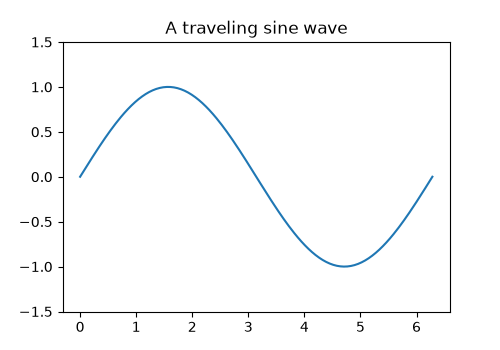

In [17]:
from IPython.display import Image
Image(filename="traveling_wave.gif")

# Practice Example 1: Plotting Two Functions

Let's put the basics together on two less-standard functions: $f(x) = \sin(x^2)$ and $g(x) = \cos\left(\frac{x^3}{3}\right) + x$, over $x \in [-3, 3]$. Both functions oscillate increasingly quickly as $|x|$ grows (since the argument to sin/cos is growing faster than linearly), so we need enough sample points for the curves to look smooth rather than jagged. We'll show them both together on one panel, and then again side by side for a cleaner individual look.

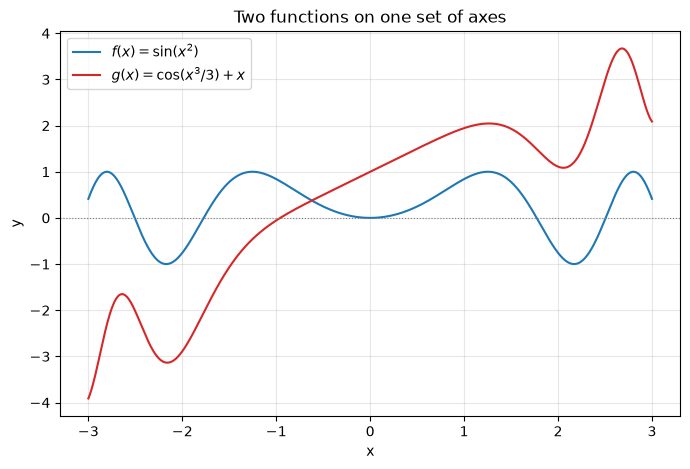

In [18]:
x_ex1 = np.linspace(-3, 3, 1000)          # 1000 points: needed for a smooth curve since sin(x^2) oscillates fast
f = np.sin(x_ex1**2)                       # f(x) = sin(x^2)
g = np.cos(x_ex1**3 / 3) + x_ex1           # g(x) = cos(x^3/3) + x

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_ex1, f, color="tab:blue", linewidth=1.5, label=r"$f(x) = \sin(x^2)$")
ax.plot(x_ex1, g, color="tab:red", linewidth=1.5, label=r"$g(x) = \cos(x^3/3) + x$")
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")  # A faint reference line at y=0
ax.set_title("Two functions on one set of axes")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

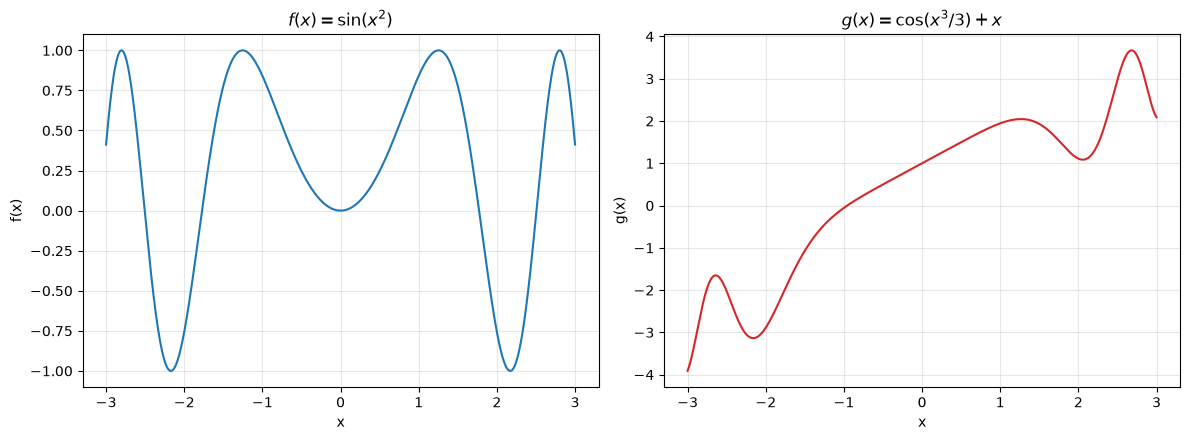

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)  # Side by side, sharing the x-axis for easy comparison

axs[0].plot(x_ex1, f, color="tab:blue")
axs[0].set_title(r"$f(x) = \sin(x^2)$")
axs[0].set_xlabel("x")
axs[0].set_ylabel("f(x)")
axs[0].grid(True, alpha=0.3)

axs[1].plot(x_ex1, g, color="tab:red")
axs[1].set_title(r"$g(x) = \cos(x^3/3) + x$")
axs[1].set_xlabel("x")
axs[1].set_ylabel("g(x)")
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Practice Example 2: Plotting a Fractal (the Mandelbrot Set)

Following the approach in NumPy's own [Plotting Fractals tutorial](https://numpy.org/numpy-tutorials/tutorial-plotting-fractals/#creating-your-own-fractals), we'll draw the **Mandelbrot set**. For every point $c$ in the complex plane, we repeatedly apply

$$z_{n+1} = z_n^2 + c, \qquad z_0 = 0$$

and ask: does $|z_n|$ stay bounded forever, or does it "escape" to infinity? Points where it stays bounded (after many iterations) belong to the Mandelbrot set; points that escape are colored by *how quickly* they escaped, which is what produces the famous fractal image.

We build this entirely with vectorized NumPy operations (no nested Python loops over every pixel), reusing exactly the `np.meshgrid` idea from the density plots section, but this time treating the grid as complex numbers `c = X + 1j * Y`.

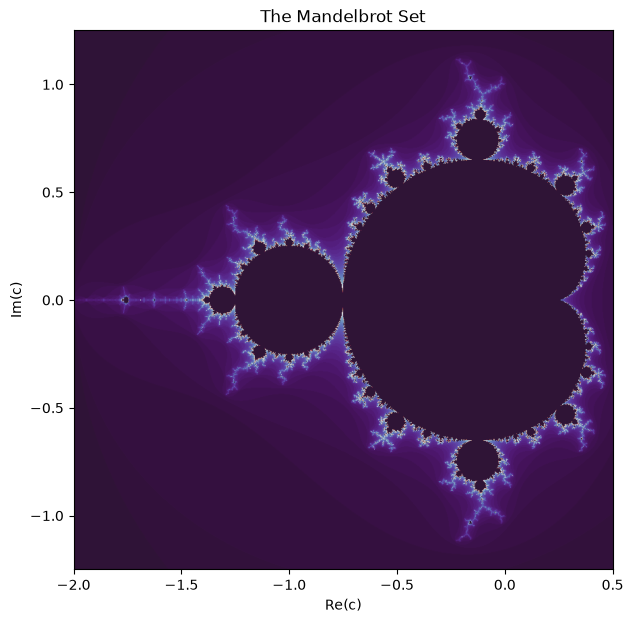

In [20]:
def mandelbrot(width, height, x_range=(-2.0, 0.5), y_range=(-1.25, 1.25), max_iter=100):
    # Returns an array of escape iteration counts for a grid of complex points c = x + i*y.
    x = np.linspace(*x_range, width)                 # Real-axis coordinates
    y = np.linspace(*y_range, height)                # Imaginary-axis coordinates
    X, Y = np.meshgrid(x, y)                          # A grid of coordinates, just like in the contour plots section
    C = X + 1j * Y                                    # Treat the grid as complex numbers c = x + iy

    Z = np.zeros_like(C)                              # z_0 = 0 for every point, same shape as C
    escape_iter = np.full(C.shape, max_iter, dtype=int)  # Assume "never escapes" (max_iter) until proven otherwise
    still_active = np.ones(C.shape, dtype=bool)       # Which points haven't escaped yet

    for i in range(max_iter):
        Z[still_active] = Z[still_active] ** 2 + C[still_active]  # Update only the points still in play
        escaped_now = np.abs(Z) > 2                    # |z| > 2 guarantees eventual escape to infinity
        newly_escaped = escaped_now & still_active      # Points escaping for the FIRST time on this iteration
        escape_iter[newly_escaped] = i                  # Record how many iterations they took
        still_active &= ~escaped_now                    # Remove them from further consideration

    return escape_iter

escape_counts = mandelbrot(width=800, height=800, max_iter=100)  # Compute the fractal grid

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(escape_counts, extent=[-2.0, 0.5, -1.25, 1.25], cmap="twilight_shifted")  # Color by escape speed
ax.set_title("The Mandelbrot Set")
ax.set_xlabel("Re(c)")
ax.set_ylabel("Im(c)")
plt.show()

Zooming into a small region (by narrowing `x_range`/`y_range` and reusing the same `mandelbrot` function) reveals more fine structure, one of the hallmark features of a fractal: it looks intricate no matter how far you zoom in.

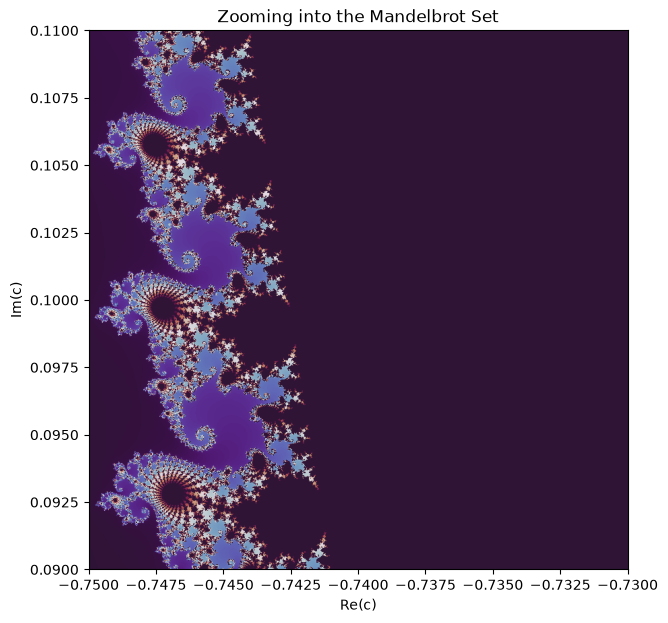

In [21]:
zoomed = mandelbrot(width=800, height=800,
                     x_range=(-0.75, -0.73), y_range=(0.09, 0.11),  # A tiny window near an interesting boundary
                     max_iter=300)                                    # More iterations needed at high zoom

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(zoomed, extent=[-0.75, -0.73, 0.09, 0.11], cmap="twilight_shifted")
ax.set_title("Zooming into the Mandelbrot Set")
ax.set_xlabel("Re(c)")
ax.set_ylabel("Im(c)")
plt.show()

# Practice Example 3: Creating Your Own GIF

Let's animate one of the 3D surfaces from earlier: instead of moving the *data*, we'll slowly rotate the *camera* around a fixed surface by changing the `azim` (azimuth) angle passed to `ax.view_init()` on every frame. This reuses the exact `FuncAnimation` + `PillowWriter` pattern from before, so the only real difference is what the update function changes.

In [22]:
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D

x3 = np.linspace(-3, 3, 60)
y3 = np.linspace(-3, 3, 60)
X3, Y3 = np.meshgrid(x3, y3)
Z3 = np.sin(np.sqrt(X3**2 + Y3**2))          # The same "ripple" surface from the 3D plots section

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(projection="3d")
ax.plot_surface(X3, Y3, Z3, cmap="viridis")  # The surface is drawn ONCE; we just rotate the view of it
ax.set_title("Rotating a 3D surface")
ax.set_axis_off()                             # Hide the axes/ticks for a cleaner-looking GIF

def update(frame):
    ax.view_init(elev=30, azim=frame * 3)     # Spin the camera 3 degrees further around per frame
    return fig,

anim = FuncAnimation(fig, update, frames=120, interval=50)  # 120 frames * 3 degrees = one full 360-degree turn
anim.save("rotating_surface.gif", writer=PillowWriter(fps=24))
plt.close(fig)

print("Saved rotating_surface.gif")

Saved rotating_surface.gif


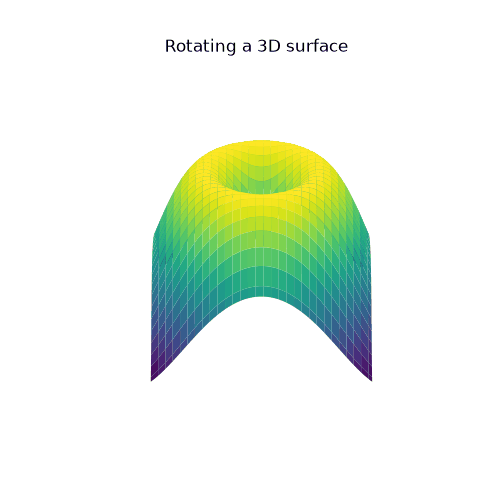

In [23]:
from IPython.display import Image
Image(filename="rotating_surface.gif")

# Practice Exercises

Now it's your turn. For each question, write your own code from scratch, don't just copy a cell above.

### Q1: A single customized plot

Plot $h(x) = x \cdot \sin(x)$ for $x$ from $-10$ to $10$ using at least 500 points. Give the line a color and linewidth of your choice, add a title, x/y axis labels, and turn on the grid. Add a horizontal reference line at $y=0$ using `ax.axhline`.

In [24]:
# TODO: your code for Q1 here

### Q2: A 2x3 grid of panels

Using `plt.subplots(nrows=2, ncols=3, ...)`, plot six different transformations of $x$ over $[0, 4\pi]$ in six panels: $\sin(x)$, $\sin(2x)$, $\sin(3x)$, $\cos(x)$, $\cos(2x)$, $\cos(3x)$. Give each panel its own title, and give the whole figure one shared title with `fig.suptitle`.

In [25]:
# TODO: your code for Q2 here

### Q3: A contour plot with a well-chosen colormap

Build a grid with `np.meshgrid` over $x, y \in [-2, 2]$ and compute $Z = X^3 - 3X + Y^2$. This function has both positive and negative values with a meaningful zero, so it calls for a *diverging* colormap. Plot it with `ax.contourf`, choosing a diverging colormap (e.g. `"RdBu"` or `"coolwarm"`), and use `TwoSlopeNorm(vcenter=0)` (see the colormaps section) so that zero maps to the center of the colormap. Add a colorbar.

In [26]:
# TODO: your code for Q3 here

### Q4: Your own animated GIF

Pick any function `f(x, t)` that depends on both `x` and a time-like parameter `t` (for example, a wave whose amplitude grows and shrinks: `np.sin(x - t) * (1 + 0.5 * np.sin(t / 5))`). Animate it over at least 60 frames and save it as a `.gif` using `FuncAnimation` and `PillowWriter`, following the pattern from Practice Example 3. Display the resulting GIF in the notebook with `IPython.display.Image`.

In [27]:
# TODO: your code for Q4 here